In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d,gaussian_filter
import pickle
from skimage import io, filters
import glob
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import psutil
from brainsss import brain_utils
from joblib import Parallel, delayed
from scipy.ndimage import uniform_filter
import gc

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
fly_num = 'fly_209'

func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'

# tf_dir = os.path.join(func_path, tf_path)
# dff_dir = os.path.join(func_path, dff_path)
tf_dir = os.path.join(func_path, 'temp_filter')
STA_dir = os.path.join(func_path, 'STA')

In [9]:
behavior = 'total'
step_size = 100
tf_file=f'functional_channel_2_moco_warp_blurred_hpf_dff_filtered_{behavior}.h5'
STA_file=f"stepsize_{step_size}_STA_{behavior}.h5"

In [15]:
%%time
with h5py.File(os.path.join(tf_dir,tf_file), 'r') as hf:
        brain = hf['brain'][:]
        ts = hf['time_stamps'][:]
        dimsb = np.shape(brain)
        dimst = np.shape(ts)
print(f"time stamp shape is {dimst}, brain shape is {dimsb}")
with h5py.File(os.path.join(STA_dir,STA_file), 'r') as hf:
        STA = hf['data'][:]
        dimss = np.shape(STA)
print(f"STA shape is {dimss}")

time stamp shape is (314, 146, 91, 1039)
STA shape is (24, 314, 146, 91)
CPU times: user 7 ms, sys: 14.6 s, total: 14.6 s
Wall time: 1min 16s


In [17]:
dimsb = np.shape(brain)
dimst = np.shape(ts)
print(f"time stamp shape is {dimst}, brain shape is {dimsb}")

time stamp shape is (314, 146, 91, 1039), brain shape is (314, 146, 91, 1039)


In [18]:
# bin_num = 100
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1,figsize=(10, 5));
# ax1 = plt.subplot(311)
# ax1_z=5
# ax1.hist(np.nanmean(STA[ax1_z], axis=-1), bins=bin_num);
# ax1.set_title(f'z={ax1_z}')
# ax2 = plt.subplot(312)
# ax2_z=14
# ax2.hist(np.nanmean(STA[ax2_z], axis=-1), bins=bin_num);
# ax2.set_title(f'z={ax2_z}')
# ax3 = plt.subplot(313)
# ax3_z=20
# ax3.hist(np.nanmean(STA[ax3_z], axis=-1), bins=bin_num);
# ax3.set_title(f'z={ax3_z}')
# print(f"MAX val: {np.nanmax(STA)} MIN val: {np.nanmin(STA)} AVG val: {np.nanmean(STA)}")

In [20]:
n_clusters = 2000
cluster_dir = os.path.join(func_path, 'func_0','clustering')

ch_num = '2'#'1'#
label_name =''
signal_name =''

for x in sorted(os.listdir(cluster_dir)):
#     print(x)
    if 'label' in x and ch_num in x and behavior in x:
        label_name = x
        load_file = os.path.join(cluster_dir, label_name)
        cluster_labels = np.load(load_file)
        print(label_name)
    if 'signals' in x and ch_num in x and behavior in x:
        signal_name = x
        load_file = os.path.join(cluster_dir, signal_name)
        all_signals = np.load(load_file)
        print(signal_name)

cluster_labels_2_total.npy
cluster_signals_2_total.npy


In [21]:
all_signals_new=np.moveaxis(all_signals,-1,1)
np.shape(all_signals_new)

(91, 1039, 2000)

In [22]:
np.shape(cluster_labels)

(91, 45844)

In [44]:
cluster_labels[14]

array([1222, 1222, 1222, ..., 1639, 1639, 1639])

In [23]:
def make_STA_brain(neural_signals, neural_timestamps, event_times_list, neural_bins):
    #### super voxel version
    
    STA_brain = []
    for z in range(49):
        all_bin_indicies = []
        for stim_idx in range(len(event_times_list)):
            stim_time = event_times_list[stim_idx]
            stim_centered_bins = neural_bins + stim_time
            bin_indicies = np.digitize(neural_timestamps[:,z] , stim_centered_bins)
            all_bin_indicies.append(bin_indicies)
        all_bin_indicies = np.asarray(all_bin_indicies)

        avg_neural_across_bins = []
        for bin_num in np.arange(1,len(neural_bins)):
            this_bin_sample_times = list(np.where(all_bin_indicies==bin_num)[1])
            average_neural_in_bin = np.mean(neural_signals[z,:,this_bin_sample_times],axis=0)
            avg_neural_across_bins.append(average_neural_in_bin)
        avg_neural_across_bins = np.asarray(avg_neural_across_bins)
        STA_brain.append(avg_neural_across_bins)
    STA_brain = np.asarray(STA_brain)
    return STA_brain

In [24]:
STA_brain = np.nan_to_num(all_signals_new)

In [25]:
def STA_supervoxel_to_full_res(STA_brain, cluster_labels):
    n_clusters = STA_brain.shape[2]
    n_tp = STA_brain.shape[1]
    brain_dims=[314,146]
    
    reformed_STA_brain = []
    for z in range(STA_brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = STA_brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_STA_brain.append(colored_by_betas)
    return np.asarray(reformed_STA_brain)


In [26]:
%%time
reformed_STA_brain = STA_supervoxel_to_full_res(STA_brain, cluster_labels)

CPU times: user 24.5 s, sys: 12.6 s, total: 37.1 s
Wall time: 37.1 s


In [27]:
print(f"MAX val: {np.max(reformed_STA_brain)} MIN val: {np.min(reformed_STA_brain)} AVG val: {np.mean(reformed_STA_brain)}")

MAX val: 4.653656959533691 MIN val: -0.8584966659545898 AVG val: 0.0006569418001108075


In [28]:
np.shape(reformed_STA_brain)

(91, 1039, 314, 146)

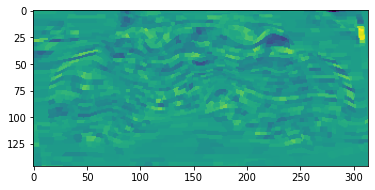

In [29]:
plt.imshow(reformed_STA_brain[25,13,:,:].T,)

In [30]:
#change the STA brain based on condition
STA_brain = gaussian_filter1d(reformed_STA_brain,sigma=1,axis=1,truncate=1)

In [31]:
print(f"MAX val: {np.max(STA_brain)} MIN val: {np.min(STA_brain)} AVG val: {np.mean(STA_brain)}")

MAX val: 2.1453040831259615 MIN val: -0.7286109229991615 AVG val: 0.0006569418001108062


In [32]:
STA_brain_temp=np.moveaxis(STA_brain,0,-1)
STA_brain_final=np.moveaxis(STA_brain_temp,0,-1).astype('float32')
dims=np.shape(STA_brain_final)

In [33]:
del reformed_STA_brain,all_signals_new,STA, STA_brain_temp
gc.collect() 

3431467

In [34]:
dims

(314, 146, 91, 1039)

In [35]:
steps=100
range_start=-500
range_end=1900
temp_STA=[]

In [36]:
%%time
for i in range(range_start, range_end, steps):
        end = i + steps if i + steps < range_end else range_end
        print(f"Vol {i} to vol{end}")
        mask = (ts > i) & (ts < end)
        result = np.nanmean(np.where(mask, STA_brain_final, np.nan), axis=-1)
        temp_STA.append(result)

Vol -500 to vol-400
Vol -400 to vol-300
Vol -300 to vol-200
Vol -200 to vol-100
Vol -100 to vol0
Vol 0 to vol100
Vol 100 to vol200
Vol 200 to vol300
Vol 300 to vol400
Vol 400 to vol500
Vol 500 to vol600
Vol 600 to vol700
Vol 700 to vol800
Vol 800 to vol900
Vol 900 to vol1000
Vol 1000 to vol1100
Vol 1100 to vol1200
Vol 1200 to vol1300
Vol 1300 to vol1400
Vol 1400 to vol1500
Vol 1500 to vol1600
Vol 1600 to vol1700
Vol 1700 to vol1800
Vol 1800 to vol1900
CPU times: user 6min 26s, sys: 5min 20s, total: 11min 46s
Wall time: 11min 46s


In [40]:
np.shape(temp_STA)

(24, 314, 146, 91)

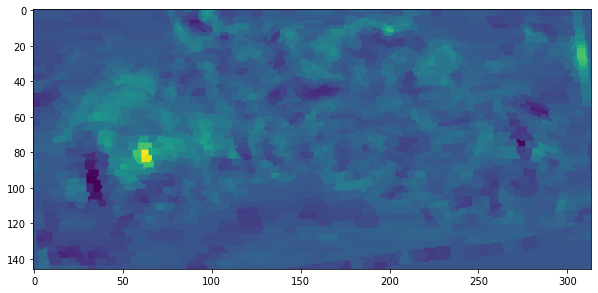

In [42]:
plt.figure(figsize=(10,10))
plt.imshow(temp_STA[14][:,:,20].T)

MAX val: 0.5099756717681885 MIN val: -0.12940585613250732 AVG val: 0.0007627706509083509


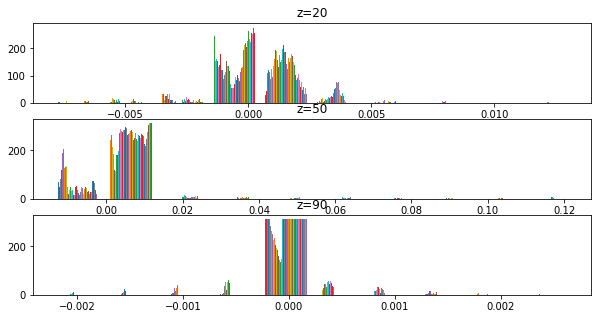

In [39]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1,figsize=(10, 5));
ax1 = plt.subplot(311)
ax1_z=20
ax1.hist(np.nanmean(temp_STA, axis=0)[...,ax1_z]);
ax1.set_title(f'z={ax1_z}')
ax2 = plt.subplot(312)
ax2_z=50
ax2.hist(np.nanmean(temp_STA, axis=0)[...,ax2_z]);
ax2.set_title(f'z={ax2_z}')
ax3 = plt.subplot(313)
ax3_z=90
ax3.hist(np.nanmean(temp_STA, axis=0)[...,ax3_z]);
ax3.set_title(f'z={ax3_z}')
print(f"MAX val: {np.nanmax(temp_STA)} MIN val: {np.nanmin(temp_STA)} AVG val: {np.nanmean(temp_STA)}")

In [ ]:
atlas = brainsss.load_roi_atlas()

In [ ]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [ ]:
explosion_rois.keys()

In [ ]:
def moving_average_2d(arr, window_size=5):
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

In [ ]:
def sort_rows_by_max_index(arr):
    # Find the index of the maximum value in each row
    arr_avg=moving_average_2d(arr,window_size=5)
    max_indices = np.argmax(arr_avg, axis=1)
    
    # Get the sorted order of the rows based on the max indices
    sorted_order = np.argsort(max_indices)
    
    # Sort the rows of the array based on the sorted order
    sorted_arr = arr[sorted_order]
    return sorted_arr

In [ ]:
%%time
total_vox_sorted={}
for area in explosion_rois:
    for key in explosion_rois[area]['rois']:
        area_name=explosion_rois[area]['rois'][key]
        if '_R' in area_name or '_L' in area_name:
            total_area_name=area_name.split('_')
            if len(total_area_name)==3:
                area_name=total_area_name[0]+'_'+total_area_name[1]
            else:
                area_name=total_area_name[0]
        roi=key
        roi_mask=roi_masks[roi]
        masked_roi=[STA[i][roi_mask] for i in range(np.shape(STA)[0])]
        masked_roi=np.transpose(masked_roi)
#         roi_sort=sort_rows_by_max_index(masked_roi)
        try:
            np.append(total_vox_sorted[area_name], masked_roi)
        except KeyError:
            total_vox_sorted[area_name]=masked_roi
for key in total_vox_sorted:
    total_vox_sorted[key]=sort_rows_by_max_index(total_vox_sorted[key])

In [ ]:
step_10=np.array([[0.00006,-0.00002],[60,160]])
step_100=np.array([[0.0003,-0.0003],[6,16]])

In [ ]:
def plot_heatmap_area(areas_dict, area, ax, step):
    if step_size==10:
        stuff=step_10
    else:
        stuff=step_100
    ax.imshow(areas_dict[area], aspect='auto',vmax=stuff[0,0], vmin=stuff[0,1], cmap='plasma')
    ax.set_ylabel(area, rotation=0, labelpad=20)
    ax.axvline(x=stuff[1,0], ymin=0, ymax=1, ls='--', color='w', lw=5)
    ax.axvline(x=stuff[1,1], ymin=0, ymax=1, ls='--', color='w', lw=5)
    ax.set_yticks([])

In [ ]:
fig = plt.figure()
axs = fig.subplots()
plot_heatmap_area(total_vox_sorted, 'MED', axs, step_size)
fig = plt.figure()
axs1 = fig.subplots()
plot_heatmap_area(total_vox_sorted, 'PB', axs1, step_size)

In [ ]:
def plot_heatmap_allareas(areas_dict):
    num_areas=len(areas_dict)
    heights = [np.shape(areas_dict[key])[0] for key in areas_dict]
#     heights=[1/x for x in heights]
    fig = plt.figure(figsize=(5,10))
    gs = fig.add_gridspec(nrows=num_areas, ncols=1, height_ratios=heights, hspace=0)
    axs = gs.subplots(sharex='col', sharey=False)
    for i,key in enumerate(areas_dict):
        plot_heatmap_area(areas_dict, key, axs[i],step_size)
    for ax in axs:
        ax.label_outer()
#         ax.spines['top'].set_visible(False)
#         ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
#         ax.set_yticks([])
        
    plt.show()

In [ ]:
areas = int((len(total_vox_sorted)+1)/5)
for i in range(0,len(total_vox_sorted), areas):
    end = i + areas if i + areas < len(total_vox_sorted) else len(total_vox_sorted)
    sliced_keys = list(total_vox_sorted.keys())[i:end]
    sliced_dict = {k: total_vox_sorted[k] for k in sliced_keys if k in total_vox_sorted}
    plot_heatmap_allareas(sliced_dict)

In [ ]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
save_dir = os.path.join(later_dir,'temp_filter')
if os.path.exists(save_dir)==False:
    os.mkdir(save_dir)
print(save_dir)

In [ ]:
%%time
STA=np.asarray(STA)


save_path = os.path.join(save_dir, fly_num+'.npy')
np.save(save_path,STA)

In [ ]:
# np.shape(data_dict['signals'])

In [ ]:
for x in sorted(os.listdir(save_dir)):
    print(x)

In [ ]:
len(os.listdir(save_dir))

In [ ]:
atlas = brainsss.load_roi_atlas()

In [ ]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [ ]:
explosions = []
t0 = time.time()
for tp in range(np.shape(STA)[0]):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    data_to_plot = STA[tp][:,:,::-1]
    vmax = 0.003 #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap='seismic', diverging=True)#'hot')
    explosions.append(explosion_map)
print(F'Explosion {time.time()-t0}')

In [ ]:
np.shape(explosions)

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(explosions[16][170:,:])

In [ ]:
movie_dir = os.path.join(func_path, 'movies')
if os.path.exists(movie_dir)==False:
    os.mkdir(movie_dir)
print(movie_dir)

In [ ]:
save_dir = os.path.join(movie_dir,f'temp_supervox_{behavior}')
if os.path.exists(save_dir)==False:
    os.mkdir(save_dir)
print(save_dir)

In [ ]:
plt.figure(figsize=(10,10))
for i in range(np.shape(STA)[0]):
    print(i)
    plt.imshow(explosions[i][170:,:]) #this was made with cmap=hot
    plt.axis('off')
    fname = os.path.join(save_dir, '{0:05d}.png'.format(i))
    plt.savefig(fname,dpi=300,bbox_inches='tight')